<div align="center">
  <img src="logo_utem.png" alt="Logo UTEM" width="120" style="max-height:140px; height:auto;"/>
  <br><br>
  <p style="margin:2px 0; font-size:16px; font-weight:400;">UNIVERSIDAD TECNOLOGICA METROPOLITANA</p>
  <p style="margin:2px 0; font-size:14px; font-weight:400;">INGENIERIA CIVIL EN CIENCIA DE DATOS</p>
  <p style="margin:2px 0; font-size:14px; font-weight:400;">INFB8090 - COMPUTACION PARALELA Y DISTRIBUIDA</p>
  <br><br>
  <h2 style="margin:0;">LABORATORIO N 6</h2>
  <br>
  <h1 style="margin:0;"><i>Cluster Orquestador Genérico</i></h1>
  <br><br>
  <p style="margin:2px 0;">Profesor: Michael Miranda Sandoval</p>
  <p style="margin:2px 0;">Integrante: Diego Silva Madariaga/Pablo Ibañez</p>
  <p style="margin:2px 0;">Fecha: 18 de junio de 2026</p>
</div>

<div align="center">
  <p style="font-size:11px; color:#8a8a8a; margin:6px 0 0 0;">
    Equipo utilizado: AMD Ryzen 7 5700X | 16 GB RAM | NVIDIA GeForce RTX 4060
  </p>
</div>

### Introduccion

Este ejercicio implementa un orquestador genérico de tareas sobre un cluster de máquinas virtuales QEMU/Alpine Linux. El coordinador no conoce el dominio del problema, y cualquier tarea nueva puede incorporarse sin modificar el sistema base. Se implementaron y evaluaron tres tareas (conteo de primos, conteo de palabras y estimación de π por Monte Carlo) ejecutadas en configuraciones de 2 y 4 workers, midiendo speedup respecto a una ejecución secuencial baseline.

## Arquitectura 

El sistema tiene tres componentes principales:

- Coordinador (coordinator_generic.py): corre en nodo0. Recibe como parámetro el archivo de tarea, lo importa, divide el trabajo en chunks y los envía a los workers. Cuando todos responden, combina los resultados.

- Worker (worker_agent.py): corre en nodo1, nodo2, etc. Es un servidor TCP que escucha en el puerto 9000. No sabe nada del dominio del problema: simplemente recibe un chunk, importa el módulo de tarea correspondiente y ejecuta run(chunk).

- Módulos de tarea (task_primes.py, task_wordcount.py, task_montecarlo.py): contienen la lógica del problema. Cada uno define tres funciones: split divide el trabajo, run procesa un chunk y merge combina los resultados parciales.

La red usa QEMU user-networking: los puertos 2220–2224 del host redirigen al SSH de cada VM, y los puertos 9001–9004 redirigen al puerto 9000 de cada worker.

1. Inicio del cluster: Se ejecuta start-2workers.ps1  que levanta 3 máquinas virtuales en QEMU: nodo0 (coordinador) y nodo1/nodo2... (workers), cada una corriendo Alpine Linux.

2. Preparación de los workers: Se copian via SCP el agente (worker_agent.py) y los módulos de tarea a cada nodo worker. Luego se inicia worker_agent.py en cada uno, que es un servidor TCP que queda escuchando en el puerto 9000 esperando trabajo.

3. Ejecución del coordinador: Se ejecuta coordinator_generic.py en nodo0 indicando la tarea, el payload y la lista de workers. Antes de distribuir trabajo, verifica que cada worker esté respondiendo (health-check).

4. División del trabajo: El coordinador llama a split() del módulo de tarea para dividir el problema en chunks. Con 2 workers buscando primos hasta 300.000, nodo1 recibe el rango 2–150.000 y nodo2 recibe 150.001–300.000.

5. Ejecución distribuida: Cada worker recibe su chunk via TCP, ejecuta run() con ese rango y devuelve el resultado parcial al coordinador.

6. Consolidación: El coordinador recibe todos los resultados parciales, llama a merge() para combinarlos y guarda el resultado final en resultado.json.

Esta separación garantiza que la plataforma nunca necesita conocer el dominio del problema.

```python
def split(payload: dict, workers: list) -> list[dict]:
    """Divide el problema en N chunks (uno por worker)."""

def run(chunk: dict) -> dict:
    """Ejecuta un chunk. Corre dentro del worker remoto."""

def merge(results: list[dict]) -> dict:
    """Combina resultados parciales en el coordinador."""
```


Protocolo de comunicación


**Mensaje enviado al worker:**
```json
{
  "job_id": "job-20260616-171852-44fb09",
  "chunk_id": 0,
  "task_name": "task_primes",
  "chunk": {"start": 2, "end": 75000}
}
```

**Respuesta del worker:**
```json
{
  "ok": true,
  "chunk_id": 0,
  "result": {"prime_count": 7236},
  "seconds": 1.547
}
```

Robustez y diagnóstico

El sistema implementa las siguientes medidas de robustez:

- Health-check antes de ejecutar: el coordinador verifica que cada worker responde antes de iniciar el job [nodo1] OK, [nodo2] OK.
- Reintentos automáticos: cada chunk tiene hasta 3 intentos ante fallo. El resultado final reporta reintentos_totales.
- Estados por chunk: pendiente → en ejecución → completado / fallido → reintento.
- Trazabilidad: cada mensaje lleva job_id y chunk_id únicos para deduplicación y diagnóstico.
- Errores explícitos: si un chunk falla definitivamente, se reporta la razón; no se ocultan errores silenciosos.
- Despliegue con no-deploy: flag para omitir copia SSH cuando los archivos ya están en los workers.

## tareas implementadas

| Tarea | split | run | merge |
|---|---|---|---|
| task_primes.py | Rangos numéricos  | Identificar primos en el rango | Suma prime_count |
| task_wordcount.py | Lotes de líneas de texto | Tokeniza y cuenta palabras | Une diccionarios de frecuencia |
| task_montecarlo.py | Lotes de muestras aleatorias | Simula puntos en círculo unitario | Estima π promediando fracciones |

## Evidencia experimental — Resultados de ejecución

Se ejecutaron las tres tareas en configuraciones de 2 y 4 workers. Para cada una se midió el tiempo en modo distribuido y en modo secuencial (baseline), calculando el speedup como T_secuencial / T_distribuido.

In [1]:
import json

b2 = json.load(open('benchmark_2.json'))
b4 = json.load(open('benchmark_4.json'))

print(f"{'Tarea':<28} {'Workers':>7} {'Chunks':>6} {'T_seq (s)':>10} {'T_dist (s)':>11} {'Speedup':>8}")
print('=' * 75)
for bm in [b2, b4]:
    n = bm['n_workers']
    for t in bm['tareas']:
        print(f"{t['label']:<28} {n:>7} {t['chunks']:>6} "
              f"{t['t_secuencial']:>10.3f} {t['t_distribuido']:>11.3f} {t['speedup']:>8.3f}x")

Tarea                        Workers Chunks  T_seq (s)  T_dist (s)  Speedup
Primos (upper=300000)              2      2      5.777       5.087    1.136x
Wordcount (100k palabras)          2      2      0.365       0.481    0.759x
Monte Carlo (2M muestras)          2      2     10.858       8.326    1.304x
Primos (upper=300000)              4      4      4.752       3.145    1.511x
Wordcount (100k palabras)          4      4      0.334       0.376    0.888x
Monte Carlo (2M muestras)          4      4     10.535       4.555    2.313x


In [7]:
import json

b2 = json.load(open('benchmark_2.json'))
b4 = json.load(open('benchmark_4.json'))

print('Verificacion de correctitud:\n')
for bm in [b2, b4]:
    n = bm['n_workers']
    for t in bm['tareas']:
        if t['tarea'] == 'task_primes':
            dist = t['resultado_dist']['total_primes']
            seq  = t['resultado_seq']['total_primes']
            ok   = 'OK' if dist == seq else 'FALLO'
            print(f"  {ok} Primos ({n}w): dist={dist}, seq={seq}")
        elif t['tarea'] == 'task_wordcount':
            dist = t['resultado_dist']['total_tokens']
            seq  = t['resultado_seq']['total_tokens']
            ok   = 'OK' if dist == seq else 'FALLO'
            print(f"  {ok} Wordcount ({n}w): dist={dist}, seq={seq}")
        elif t['tarea'] == 'task_montecarlo':
            pi_d = t['resultado_dist']['pi_estimate']
            pi_s = t['resultado_seq']['pi_estimate']
            print(f"  OK Monte Carlo ({n}w): pi_dist={pi_d:.6f}, pi_seq={pi_s:.6f}")

Verificacion de correctitud:

  OK Primos (2w): dist=25997, seq=25997
  OK Wordcount (2w): dist=100000, seq=100000
  OK Monte Carlo (2w): pi_dist=3.140184, pi_seq=3.141602
  OK Primos (4w): dist=25997, seq=25997
  OK Wordcount (4w): dist=100000, seq=100000
  OK Monte Carlo (4w): pi_dist=3.139970, pi_seq=3.141602


## Gráfico de speedup

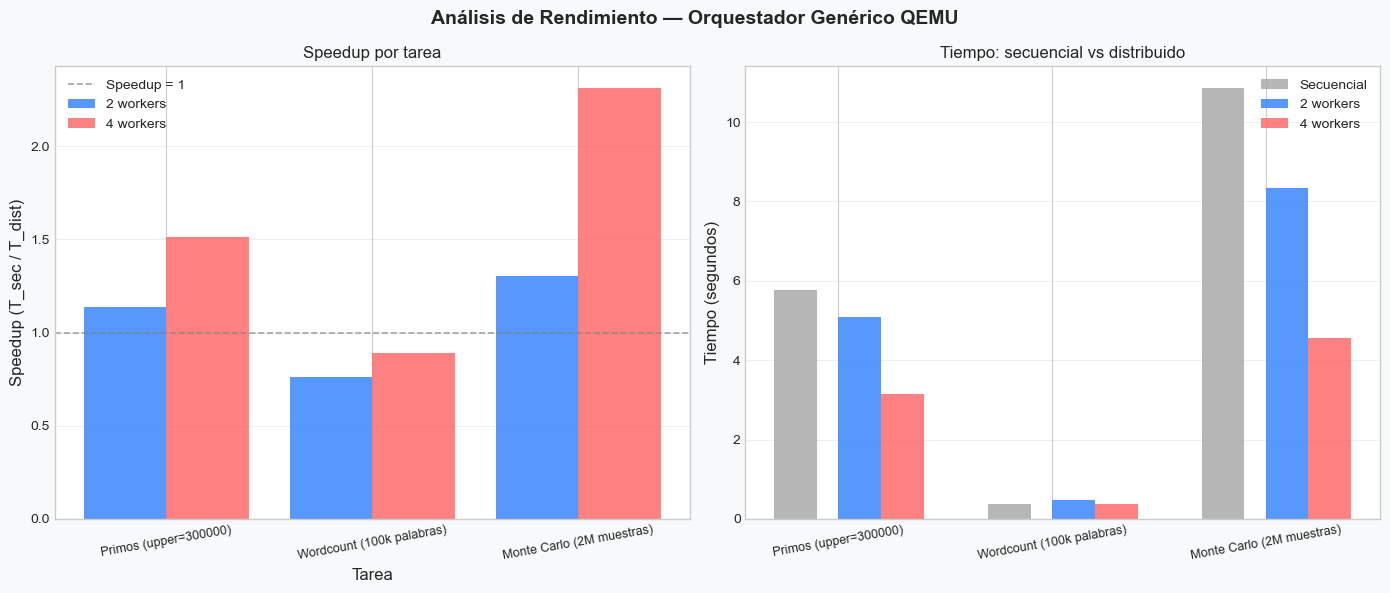

In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

b2 = json.load(open('benchmark_2.json'))
b4 = json.load(open('benchmark_4.json'))
datos = {2: b2, 4: b4}

tareas      = [t['tarea'] for t in b2['tareas']]
labels_dict = {t['tarea']: t['label'] for t in b2['tareas']}
ns          = [2, 4]
bar_colores = ['#3A86FF', '#FF6B6B']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Análisis de Rendimiento — Orquestador Genérico QEMU', fontsize=14, fontweight='bold')
fig.patch.set_facecolor('#F8F9FA')

ax1   = axes[0]
x     = np.arange(len(tareas))
ancho = 0.8 / len(ns)

for j, n in enumerate(ns):
    speedups = [next(t['speedup'] for t in datos[n]['tareas'] if t['tarea'] == tarea) for tarea in tareas]
    offset   = (j - len(ns) / 2 + 0.5) * ancho
    ax1.bar(x + offset, speedups, width=ancho, label=f'{n} workers',
            color=bar_colores[j], alpha=0.85)

ax1.axhline(y=1, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, label='Speedup = 1')
ax1.set_xlabel('Tarea', fontsize=12)
ax1.set_ylabel('Speedup (T_sec / T_dist)', fontsize=12)
ax1.set_title('Speedup por tarea', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels([labels_dict[t] for t in tareas], fontsize=9, rotation=10)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(bottom=0)

ax2    = axes[1]
ancho2 = 0.2
t_seq  = [next(t['t_secuencial'] for t in b2['tareas'] if t['tarea'] == tarea) for tarea in tareas]
ax2.bar(x - ancho2, t_seq, width=ancho2, label='Secuencial', color='#AAAAAA', alpha=0.85)

for j, n in enumerate(ns):
    t_dist = [next(t['t_distribuido'] for t in datos[n]['tareas'] if t['tarea'] == tarea) for tarea in tareas]
    offset = (j - len(ns) / 2 + 0.5) * ancho2
    ax2.bar(x + offset + ancho2, t_dist, width=ancho2,
            label=f'{n} workers', color=bar_colores[j], alpha=0.85)

ax2.set_xticks(list(x))
ax2.set_xticklabels([labels_dict[t] for t in tareas], fontsize=9, rotation=10)
ax2.set_ylabel('Tiempo (segundos)', fontsize=12)
ax2.set_title('Tiempo: secuencial vs distribuido', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('speedup_comparativo.png', dpi=150, bbox_inches='tight')
plt.show()

## Análisis 

- Monte Carlo con 2M muestras alcanza speedup 2.31x con 4 workers porque el cómputo por chunk es intensivo (~4s por worker) y el overhead de red es despreciable comparado al trabajo realizado. Es el caso ideal para cómputo distribuido.

- El conteo de 100k palabras tarda ~0.35s en modo secuencial. El overhead de serialización JSON, conexión TCP y deserialización entre coordinador y workers supera el beneficio del paralelismo para cargas tan pequeñas. Speedup < 1 no indica un error: indica que la tarea es demasiado ligera para justificar distribución.

El speedup ideal para N workers sería N (2x con 2, 4x con 4). Los speedups observados son significativamente menores porque:
1. Overhead de red: cada chunk requiere una conexión TCP, serialización y deserialización JSON.
2. Desbalance de carga: los workers no terminan al mismo tiempo (el job espera al más lento).
3. Emulación QEMu: las VMs comparten CPU del host, no son núcleos reales independientes.
4. Overhead del coordinador: el merge y la gestión de chunks consumen tiempo en nodo0.


El sistema presenta las siguientes limitaciones. El número de chunks es fijo e igual al número de workers, por lo que no hay cola dinámica que aproveche workers más rápidos. El despliegue SSH requiere que los workers sean accesibles desde nodo0, lo que depende de la configuración de red de QEMU. Los speedups están acotados por el hecho de que las VMs comparten la CPU física del host, por lo que el paralelismo es emulado y no equivale a núcleos reales independientes. Finalmente, si un worker cae durante la ejecución, los reintentos se dirigen al mismo nodo caído.

## 9. Archivos entregados

| Archivo | Descripción |
|---|---|
| `coordinator_generic.py` | Orquestador principal — carga tarea, distribuye, agrega |
| `worker_agent.py` | Agente genérico en cada nodo worker |
| `task_primes.py` | Tarea 1: conteo de primos |
| `task_wordcount.py` | Tarea 2: conteo de palabras |
| `task_montecarlo.py` | Tarea 3: estimación de π |
| `workers-2.json` | Config de 2 workers |
| `workers-4.json` | Config de 4 workers |
| `benchmark.py` | Mide tiempos distribuido vs secuencial |
| `benchmark_2.json` | Resultados con 2 workers |
| `benchmark_4.json` | Resultados con 4 workers |
| `grafico_speedup.py` | Genera gráfico de speedup |
| `speedup_comparativo.png` | Gráfico generado |
| `start-2workers.ps1` | Inicia cluster QEMU con 2 workers |
| `start-4workers.ps1` | Inicia cluster QEMU con 4 workers |
| `setup-discos.ps1` | Crea discos qcow2 para nodo3-6 |